# TP1 - Prise en main de Keras

## Préparation d'un environnement de développement
1. Ouvrir une console *Anacond Prompt* et préparer un environnement de travail sous Python 3.12 adapté à l'usage de Keras 3 (voir cours).

2. Depuis l'environnement créé, lancer Jupyter Notebook et créer un nouveau Notebook

3. Vérifier que l'instruction `import keras` s'exécute bien sans erreur

In [19]:
# Imports et fonctions utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

def show_data_img(X, n=200, shape=(28,28), dpi=100):
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    nl = n // 20
    if n%20!=0: nl += 1
    
    for i in range(n):
        plt.subplot(nl,20,i+1)
        plt.imshow(X[i,:].reshape(shape), cmap='gray')
        plt.axis('off')
    plt.plot()
    
def show_errors_img(X, Y_pred, Y_true, shape=(28,28), dpi=100):  
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    n = min(len(X), len(Y_pred), len(Y_true), 30) # 30 erreurs au maximum
    X, Y_pred, Y_true = X[:n], Y_pred[:n], Y_true[:n]
    nl = n // 10
    if n%10!=0: nl += 1 
    
    for i in range(n):
        plt.subplot(nl,10,i+1)
        x, yp, yt = X[i], Y_pred[i], Y_true[i]
        plt.imshow(x.reshape(shape), cmap='gray')
        plt.axis('off')
        plt.title(str(yp)+' ('+str(yt)+')')
    plt.plot()
    
def show_model_errors(model, X, y):
    proba = model.predict(X)
    y_pred = proba.argmax(axis=1)

    errors = [i for i in range(len(y_pred)) if y_pred[i]!=y[i]]
    show_errors_img(X[errors], y_pred[errors], y[errors])

## Classification sur MNIST
Le but de cet exercice est de construire un premier réseau de neurones adapté aux données images classiques MNIST.

MNIST est un ensemble de données constitué d’images de chiffres manuscrits. Il est directement accessible depuis la bibliothèque *Keras* : 
```python
from keras.datasets import mnist
(X_train, y_train), (X_val, y_val) = mnist.load_data()
```

Afin de faciliter l'observation de ces données, trois fonctions sont fournies (voir plus loin) : 
- `show_data_img(X)` : afficher les 200 premières données sous forme d'image
- `show_errors_img(X, Y_pred, Y_true)` : afficher les images des données avec leur prédiction et vrai classement (30 max). 
- `show_model_errors(model, X, y)` : afficher les images des données mal classées par un modèle (30 max). 

#### 1/ Observer les données
Dans un premier temps, l'objectif est d'étudier les données MNIST et de comprendre problème à résoudre au travers de ces données.
- Quelles sont les dimensions des différents ensembles (forme, taille) ?
- Afficher les valeurs de la première donnée de X_train
- Utiliser show_data_img sur X_train
- Afficher les premières données de Y_train
- Que représente les données cibles ? Quel est le problème à résoudre ?
- Qelle différence y a-t-il entre les données d'entraînement et les données de validation, ?

In [20]:
#### 1/ Observer les données
# Dans un premier temps, l'objectif est d'étudier les données MNIST et de comprendre problème à résoudre au travers de ces données.

from keras.datasets import mnist
(X_train, y_train), (X_val, y_val) = mnist.load_data()

In [21]:
# - Quelles sont les dimensions des différents ensembles (forme, taille) ?
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (60000, 28, 28)
X_val shape: (10000, 28, 28)
y_train shape: (60000,)
y_val shape: (10000,)


In [22]:
# - Afficher les valeurs de la première donnée de X_train
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

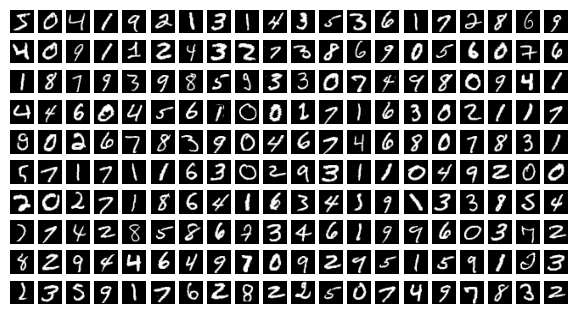

In [23]:
# - Utiliser show_data_img sur X_train
show_data_img(X_train)

In [24]:
# - Afficher les premières données de Y_train
print(y_train[:20])

[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9]


##### - Que représente les données cibles ? Quel est le problème à résoudre ? 
On veut trouver la correspondance de chanque image "données X" par rapport au données de la table Y qui sont les réponses attendues.
##### - Quelle différence y a-t-il entre les données d'entraînement et les données de validation?
C'est Keras qui sépare automatiquement la base de donnée MNIST en deux partie pour l'entrainement et la validation

#### 2/ Préparer les données 
Normaliser les données d'entrées (rapporter toutes les valeurs entre 0 et 1), puis observer de nouveau les données.


In [25]:
# - On normalise en divisant par 255 (valeur maximale d'un pixel)
X_train = X_train / 255
X_val = X_val / 255

#### 3/ Créer un réseau de neurones
Créer un modèle séquentiel (Sequential) contenant : 


In [26]:
# - Une couche d'entrée adaptée aux images MNIST
# - Une couche applatissant les données une seule dimension (qu'on ne fait pas dans notre cas)
# - Une couche de sortie permettant d'obtenir une distribution de probabilité sur les classes possible
# - Ajouter une couche de sortie avec le bon nombre de sorties
model = keras.models.Sequential()
model.add(keras.layers.Input(X_train.shape[1:]))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(10, activation='softmax'))



# Compiler le modèle en utiliser les paramètres suivants :
# - Une descente de gradient de type "Stochastic" ("sgd")
# - Un coût de type "sparse_categorical_crossentropy"
# - Comme mesure, la precision (eaccuracy")
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()


# Questions :
# - Pourquoi utiliser la "sparse_categorical_crossentropy" plutôt que la "categorical_crossentropy" ? car sparse renvoie uniquement les 1 et non les valeurs qui ont 0, ça alège le modèle 
# - Quel est le taux d'apprentissage par défaut ?
# - Comment changer le taux d'apprentissage ? 0.01 <- 'sgd' par défaut
# accuracy : nombre de prédictions correctes / nombre total de prédictions <- c'est un taux de réussite.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

#### 4/ Entrainer le réseau sur les données d'entraintenement
Entrainer le réseau pendant 20 itérations en utilisant une taille de batch de 64.

In [27]:
taille_batch = 64
nb_iterations = 100

s = model.fit(X_train, y_train, batch_size = taille_batch, epochs = nb_iterations, verbose = 1, validation_data= (X_val, y_val))

Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7600 - loss: 1.0190 - val_accuracy: 0.8641 - val_loss: 0.6104
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8640 - loss: 0.5592 - val_accuracy: 0.8815 - val_loss: 0.4807
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8770 - loss: 0.4763 - val_accuracy: 0.8899 - val_loss: 0.4291
Epoch 4/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8848 - loss: 0.4364 - val_accuracy: 0.8940 - val_loss: 0.4000
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8898 - loss: 0.4117 - val_accuracy: 0.8980 - val_loss: 0.3805
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8930 - loss: 0.3945 - val_accuracy: 0.9018 - val_loss: 0.3671
Epoch 7/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8962 - loss: 0.3817 - val_accuracy: 0.9043 - val_loss: 0.3565
Epoch 8/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8981 - loss: 0.3716 - val_accu

#### 5/ Résultats 
Restituer les résultats de l'apprentissage : 
- L'objet résultat obtenu après l'entrainement est de quel type ?
- Observer les caractéristique de ce type d'objet dans la documentation de Keras.
- Afficher le contenu du champs *history* de cet objet.
- Afficherez un graphique montrant l'évolution du taux de précision (accuracy) au fur et à mesure des itérations.
- Afficherez un graphique montrant l'évolution du coût (loss) au fur et à mesure des itérations.
- Utiliser la fonction show_model_errors sur les données de validation.

<Axes: >

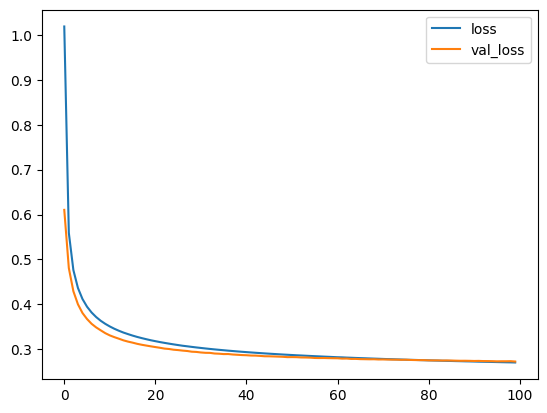

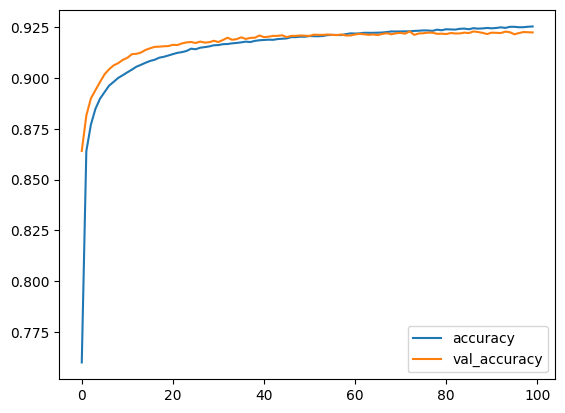

In [28]:
pd.DataFrame(s.history, columns=['loss', 'val_loss']).plot()
pd.DataFrame(s.history, columns=['accuracy', 'val_accuracy']).plot()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


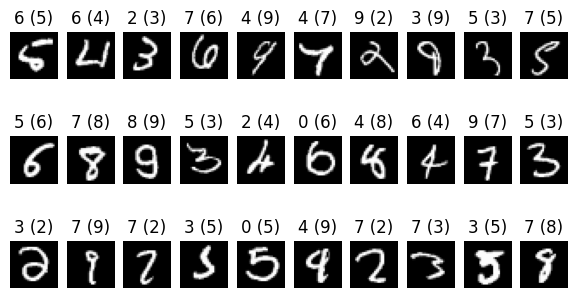

In [29]:
show_model_errors(model, X_val, y_val)

#### 6/ Tester avec d'autres architectures (pas fait car fait dans le TP2)
On souhaiterait tester d'autres architectures de réseau de neurones : 
- Créer un eautre réseau contenant une couche dense cachée de 10 neurones
- Revoir la récupération des résultats afin qu'ils soient stockées dans une dictionnaire
- Afficher des graphiques comparant les résultats des deux réseaux

Tester d'autres architectures et les ajouter aux résultats.

---